In [ ]:
pip install yfinance

In [ ]:
import yfinance as yf

# Import Libraries and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import pickle
from datetime import datetime, timedelta
import requests
import time
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore")

# Downloading BTC-USDT Data (Basic Features)

In [ ]:
def download_binance_data(symbol="BTCUSDT", interval="1h", days=250):
    print("Downloading Bitcoin HOURLY data from Binance...")

    url = "https://data-api.binance.vision/api/v3/klines"
    limit = 1000
    start_time = int((pd.Timestamp.utcnow() - pd.Timedelta(days=days)).timestamp() * 1000)

    all_klines = []

    while True:
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": start_time,
            "limit": limit
        }

        response = requests.get(url, params=params)

        try:
            data = response.json()
        except:
            print("❌ Error: response not JSON")
            print(response.text)
            break

        if isinstance(data, dict) and "code" in data:
            print("❌ Binance Error:", data)
            break

        if not data:
            break

        all_klines.extend(data)
        start_time = data[-1][0] + 1

        if len(data) < limit:
            break

    if not all_klines:
        raise ValueError("No data downloaded from Binance.")

    df = pd.DataFrame(all_klines, columns=[
        "open_time","open","high","low","close","volume",
        "close_time","quote_asset_volume","trades",
        "taker_buy_base","taker_buy_quote","ignore"
    ])

    # convert timestamps to datetime
    df["open_time"] = pd.to_datetime(df["open_time"], unit='ms')
    df["close_time"] = pd.to_datetime(df["close_time"], unit='ms')

    # Convert numeric columns
    num_cols = ["open","high","low","close","volume",
                "quote_asset_volume","taker_buy_base","taker_buy_quote"]
    df[num_cols] = df[num_cols].astype(float)

    print(f"✅ Downloaded {len(df)} rows (~{len(df)//24} days)")
    return df
btc_data = download_binance_data("BTCUSDT", "1h", 250)
btc_data.to_csv("btc_usdt.csv", index=False)

📊 Downloading Bitcoin HOURLY data from Binance...
✅ Downloaded 6000 rows (~250 days)


In [2]:
btc_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/btc_usdt.csv")

# Downloading BTC-USDT Data (Advance Features)

In [ ]:
def download_binance_data(symbol="BTCUSDT", interval="1h", days=250):
    print("📊 Downloading Bitcoin HOURLY data from Binance...")

    url = "https://data-api.binance.vision/api/v3/klines"
    limit = 1000
    start_time = int((pd.Timestamp.utcnow() - pd.Timedelta(days=days)).timestamp() * 1000)

    all_klines = []

    while True:
        params = {"symbol": symbol, "interval": interval, "startTime": start_time, "limit": limit}
        response = requests.get(url, params=params)

        try:
            data = response.json()
        except:
            print("❌ Response not JSON:", response.text)
            break

        if isinstance(data, dict) and "code" in data:
            print("❌ Binance Error:", data)
            break

        if not data:
            break

        all_klines.extend(data)
        start_time = data[-1][0] + 1

        if len(data) < limit:
            break

    if not all_klines:
        raise ValueError("No data downloaded from Binance.")

    df = pd.DataFrame(all_klines, columns=[
        "open_time","open","high","low","close","volume",
        "close_time","quote_asset_volume","trades",
        "taker_buy_base","taker_buy_quote","ignore"
    ])

    df["open_time"] = pd.to_datetime(df["open_time"], unit='ms')
    numeric_cols = ["open","high","low","close","volume","quote_asset_volume","taker_buy_base","taker_buy_quote"]
    df[numeric_cols] = df[numeric_cols].astype(float)

    print(f"✅ Downloaded {len(df)} rows (~{len(df)//24} days)")

    # ------------------------------
    # 🔥 FEATURE ENGINEERING STARTS
    # ------------------------------

    # 1. Returns
    df["return_1h"] = df["close"].pct_change()
    df["return_24h"] = df["close"].pct_change(24)

    # 2. Volatility (24h rolling std)
    df["volatility_24h"] = df["close"].rolling(window=24).std()

    # 3. Moving Averages
    df["sma_7"] = df["close"].rolling(window=7).mean()
    df["sma_21"] = df["close"].rolling(window=21).mean()
    df["sma_ratio"] = df["sma_7"] / df["sma_21"]

    # 4. Volume features
    df["volume_change"] = df["volume"].pct_change()
    df["buy_sell_ratio"] = df["taker_buy_quote"] / df["quote_asset_volume"]

    # 5. Time-based features
    df["hour"] = df["open_time"].dt.hour
    df["day_of_week"] = df["open_time"].dt.dayofweek

    # 6. Lag features
    for lag in [1, 2, 3, 6, 12, 24]:
        df[f"lag_{lag}"] = df["close"].shift(lag)

    # Remove rows with NaN (from rolling/lags)
    df = df.dropna().reset_index(drop=True)

    print("✨ Feature engineering completed!")
    print(f"📈 Final dataset shape: {df.shape}")

    return df
btc_data = download_binance_data("BTCUSDT", "1h", 250)
btc_data.to_csv("btc_usdt_features.csv", index=False)

📊 Downloading Bitcoin HOURLY data from Binance...
✅ Downloaded 6000 rows (~250 days)
✨ Feature engineering completed!
📈 Final dataset shape: (5976, 28)


# Data Preprocessing and EDA

In [39]:
# Check range
start = btc_data.index.min()
end = btc_data.index.max()
print(f"Time range: {start} to {end}")

Time range: 2025-03-20 20:00:00 to 2025-11-25 18:00:00


In [ ]:
btc_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   open_time           6000 non-null   object 
 1   open                6000 non-null   float64
 2   high                6000 non-null   float64
 3   low                 6000 non-null   float64
 4   close               6000 non-null   float64
 5   volume              6000 non-null   float64
 6   close_time          6000 non-null   object 
 7   quote_asset_volume  6000 non-null   float64
 8   trades              6000 non-null   int64  
 9   taker_buy_base      6000 non-null   float64
 10  taker_buy_quote     6000 non-null   float64
 11  ignore              6000 non-null   int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 562.6+ KB


In [ ]:
btc_data.describe()

,open,high,low,close,volume,quote_asset_volume,trades,taker_buy_base,taker_buy_quote,ignore
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6.000000e+03,6.000000e+03,6000.000000,6.000000e+03,6000.0
mean,105628.495080,105913.312067,105329.912482,105629.082532,801.028627,8.293297e+07,1.386853e+05,387.926141,4.016950e+07,0.0
std,11388.909122,11373.423667,11401.488060,11387.890753,867.182654,8.604401e+07,1.230173e+05,432.793264,4.293315e+07,0.0
min,74810.000000,75491.060000,74508.000000,74810.010000,55.663110,5.969275e+06,9.791000e+03,18.912180,2.029111e+06,0.0
25%,101285.872500,101626.322500,100742.047500,101285.880000,345.487223,3.673719e+07,6.324650e+04,159.512197,1.688544e+07,0.0
50%,108253.090000,108500.000000,107972.540000,108253.090000,562.688420,5.923456e+07,1.025330e+05,268.116915,2.795764e+07,0.0
75%,114260.107500,114508.245000,113967.007500,114260.105000,933.817610,9.831623e+07,1.727940e+05,453.539290,4.769068e+07,0.0
max,126011.180000,126199.630000,125252.740000,126011.180000,22932.630340,2.527603e+09,3.520247e+06,10873.732750,1.199587e+09,0.0


In [ ]:
btc_data.dtypes

,0
open_time,object
open,float64
high,float64
low,float64
close,float64
volume,float64
close_time,object
quote_asset_volume,float64
trades,int64
taker_buy_base,float64


In [3]:
btc_data['open_time'] = pd.to_datetime(btc_data['open_time'])

In [ ]:
btc_data.set_index('open_time', inplace=True)

In [4]:
btc_data.dtypes

,0
open_time,datetime64[ns]
open,float64
high,float64
low,float64
close,float64
volume,float64
close_time,object
quote_asset_volume,float64
trades,int64
taker_buy_base,float64


In [ ]:
btc_data.head()

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,trades,taker_buy_base,taker_buy_quote,ignore
0,2025-03-20 19:00:00,84060.53,84419.99,83922.00,84174.79,556.02857,2025-03-20 19:59:59.999,4.680934e+07,116589,262.47723,2.210179e+07,0
1,2025-03-20 20:00:00,84176.87,84609.21,84141.30,84530.10,484.79628,2025-03-20 20:59:59.999,4.094819e+07,54246,231.98689,1.959456e+07,0
2,2025-03-20 21:00:00,84530.09,84601.89,84250.67,84350.00,411.19854,2025-03-20 21:59:59.999,3.470855e+07,52659,215.08585,1.814894e+07,0
3,2025-03-20 22:00:00,84350.00,84500.00,83980.58,84141.31,494.26998,2025-03-20 22:59:59.999,4.160970e+07,84641,190.72488,1.605823e+07,0
4,2025-03-20 23:00:00,84141.30,84360.00,83922.01,84223.39,401.49858,2025-03-20 23:59:59.999,3.377439e+07,72893,222.11303,1.868444e+07,0


In [5]:
btc_data.drop(['ignore','close_time'], axis=1, inplace=True)

In [6]:
btc_data.head()

,open_time,open,high,low,close,volume,quote_asset_volume,trades,taker_buy_base,taker_buy_quote
0,2025-03-20 19:00:00,84060.53,84419.99,83922.00,84174.79,556.02857,4.680934e+07,116589,262.47723,2.210179e+07
1,2025-03-20 20:00:00,84176.87,84609.21,84141.30,84530.10,484.79628,4.094819e+07,54246,231.98689,1.959456e+07
2,2025-03-20 21:00:00,84530.09,84601.89,84250.67,84350.00,411.19854,3.470855e+07,52659,215.08585,1.814894e+07
3,2025-03-20 22:00:00,84350.00,84500.00,83980.58,84141.31,494.26998,4.160970e+07,84641,190.72488,1.605823e+07
4,2025-03-20 23:00:00,84141.30,84360.00,83922.01,84223.39,401.49858,3.377439e+07,72893,222.11303,1.868444e+07


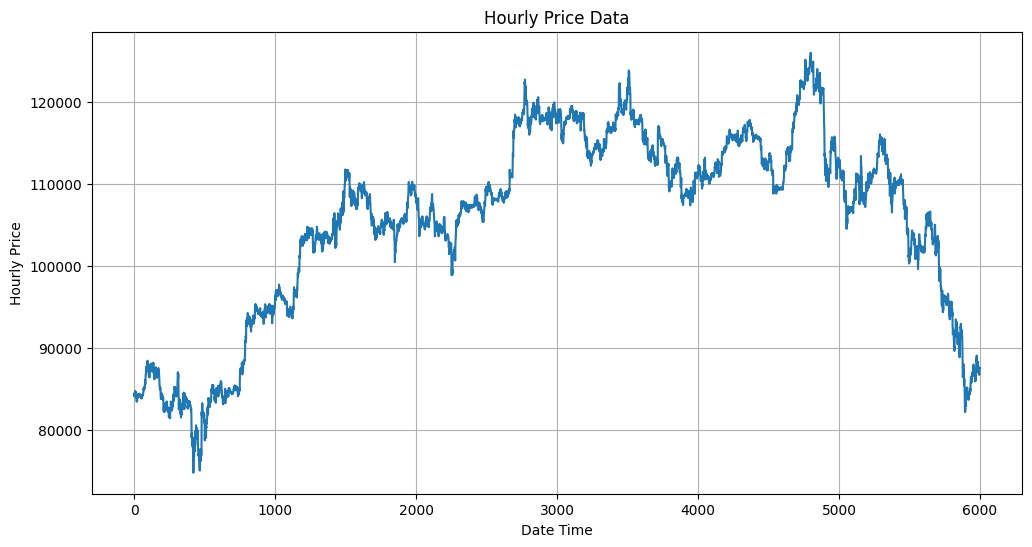

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(btc_data['close'])
plt.title("Hourly Price Data")
plt.xlabel("Date Time")
plt.ylabel("Hourly Price")
plt.grid(True)
plt.show()

In [ ]:
btc_data.isnull().sum()

,0
open_time,0
open,0
high,0
low,0
close,0
volume,0
quote_asset_volume,0
trades,0
taker_buy_base,0
taker_buy_quote,0


# Checking Data Stationary or Not

In [ ]:
def test_stationarity(timeseries):
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    return dfoutput

result = test_stationarity(btc_data['close'])
print(result)

print("="*50)
if result['Test Statistic'] < result['Critical Value (1%)'] and result['Test Statistic'] < result['Critical Value (5%)'] and result['Test Statistic'] < result['Critical Value (10%)']:
    print("Based on first observation, Data is stationary")
if result['p-value'] < 0.05:
    print("Based on second observation, Data is stationary")
else:
    print("Data is not stationary")
# Null Hypothesis: Data is not stationary
# if p-value is less than 0.05 then we reject the null hypothesis and our data is stationary
# if Test Statistic is less than Critical Value then we reject the null hypothesis and our data is stationary

Test Statistic                   -1.634676
p-value                           0.465044
#Lags Used                        4.000000
Number of Observations Used    5995.000000
Critical Value (1%)              -3.431441
Critical Value (5%)              -2.862022
Critical Value (10%)             -2.567027
dtype: float64
Data is not stationary


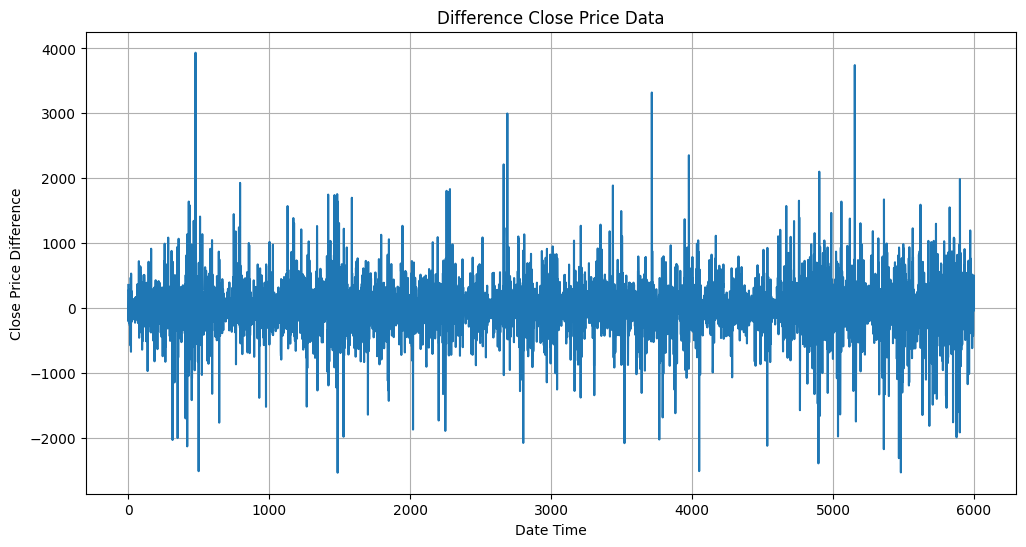

In [7]:
btc_data['close_diff'] = btc_data['close'] - btc_data['close'].shift(1)
btc_data.dropna(inplace=True)

plt.figure(figsize=(12,6))
plt.plot(btc_data['close_diff'])
plt.title("Difference Close Price Data")
plt.xlabel("Date Time")
plt.ylabel("Close Price Difference")
plt.grid(True)
plt.show()

In [ ]:
result = test_stationarity(btc_data['close_diff'])
print(result)
print("="*50)
if result['Test Statistic'] < result['Critical Value (1%)'] and result['Test Statistic'] < result['Critical Value (5%)'] and result['Test Statistic'] < result['Critical Value (10%)']:
    print("Based on first observation, Data is stationary")
if result['p-value'] < 0.05:
    print("Based on second observation, Data is stationary")
else:
    print("Data is not stationary")

Test Statistic                  -37.675530
p-value                           0.000000
#Lags Used                        3.000000
Number of Observations Used    5995.000000
Critical Value (1%)              -3.431441
Critical Value (5%)              -2.862022
Critical Value (10%)             -2.567027
dtype: float64
Based on first observation, Data is stationary
Based on second observation, Data is stationary


In [8]:
btc_data.dropna()

,open_time,open,high,low,close,volume,quote_asset_volume,trades,taker_buy_base,taker_buy_quote,close_diff
1,2025-03-20 20:00:00,84176.87,84609.21,84141.30,84530.10,484.79628,4.094819e+07,54246,231.98689,1.959456e+07,355.31
2,2025-03-20 21:00:00,84530.09,84601.89,84250.67,84350.00,411.19854,3.470855e+07,52659,215.08585,1.814894e+07,-180.10
3,2025-03-20 22:00:00,84350.00,84500.00,83980.58,84141.31,494.26998,4.160970e+07,84641,190.72488,1.605823e+07,-208.69
4,2025-03-20 23:00:00,84141.30,84360.00,83922.01,84223.39,401.49858,3.377439e+07,72893,222.11303,1.868444e+07,82.08
5,2025-03-21 00:00:00,84223.38,84535.27,84180.09,84507.07,382.39992,3.227288e+07,62981,192.18549,1.621850e+07,283.68
...,...,...,...,...,...,...,...,...,...,...,...
5995,2025-11-25 14:00:00,87083.00,87298.35,86116.00,86741.55,1997.11968,1.733613e+08,477724,889.99958,7.725636e+07,-341.46
5996,2025-11-25 15:00:00,86741.55,87300.00,86200.00,86988.94,1227.12482,1.064729e+08,381330,790.54798,6.861221e+07,247.39
5997,2025-11-25 16:00:00,86988.93,87291.00,86712.35,87121.31,678.88146,5.910916e+07,242305,340.69844,2.966744e+07,132.37
5998,2025-11-25 17:00:00,87121.31,88155.65,87046.09,87625.89,918.86754,8.053790e+07,243467,499.48545,4.377583e+07,504.58


# Preparing Data for Model Training

In [9]:
print(f"Date range: {btc_data.index[0]} to {btc_data.index[-1]}")

Date range: 1 to 5999


In [10]:
# Step 2: Prepare the data
print("\n🔧 Preparing data for model...")
print(f"Current BTC price: ${btc_data['close'].iloc[-1]:,.2f}\n")


🔧 Preparing data for model...
Current BTC price: $87,588.64



In [11]:
# Use closing price for prediction
data = btc_data[['close']].values

In [12]:
print(data)

[[84530.1 ]
 [84350.  ]
 [84141.31]
 ...
 [87121.31]
 [87625.89]
 [87588.64]]


# Using Min-Max Scaler

In [ ]:
# Normalize the data (scale between 0 and 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Using StandardScaler()

**Best Results with standard scaler:**

In [13]:
# Normalize the data (scale between 0 and 1)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

In [14]:
# Create sequences (use past 24 hours to predict next 1 hour)
sequence_length = 24  # Last 24 hours
X = []  # Input sequences
y = []  # Target values

# Training and Testing Splitting

In [15]:
for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

# Reshape X for LSTM [samples, time steps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Split into training and testing sets (80% train, 20% test)
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Using last {sequence_length} hours to predict next 1 hour")

Training samples: 4780
Testing samples: 1195
Using last 24 hours to predict next 1 hour


# **TRAINING MODELS**

# 1. LSTM MODEL

**WITH 5 LAYERS STARTING FROM 64 NEURONS:**

In [ ]:
# Step 3: Build the LSTM model
print("\n🧠 Building LSTM Neural Network...")
model = Sequential([
    # First LSTM layer
    LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.3),

    # Second LSTM layer
    LSTM(units=64, return_sequences=True),
    Dropout(0.3),

    # Third LSTM layer
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),

    # Dense layer
    Dense(units=16, activation='relu'),

    # Output layer
    Dense(units=1)
])


🧠 Building LSTM Neural Network...


**WITH 5 LAYERS STARTING FROM 128 NEURONS:**

In [ ]:
# Step 3: Build the LSTM model
print("\n🧠 Building LSTM Neural Network...")
model = Sequential([
    # First LSTM layer
    LSTM(units=128, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.3),

    # Second LSTM layer
    LSTM(units=64, return_sequences=True),
    Dropout(0.3),

    # Third LSTM layer
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),

    # Dense layer
    Dense(units=16, activation='relu'),

    # Output layer
    Dense(units=1)
])


🧠 Building LSTM Neural Network...


**Compiling LSTM Model**

In [ ]:
# Compile the model with better optimizer settings
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)
print("✅ Model architecture created")
print(f"Total parameters: {model.count_params():,}")

**1. HyperParameter Tunning:** Without Earlystopping and RONPlateu Learning Rate tweaks + 50 epochs

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32, # means it will send 32 samples at a time to epoch untill it reach total limit like here is 1000
    verbose = 1
)

Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.1732 - mae: 0.2582
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0243 - mae: 0.1126
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0196 - mae: 0.1021
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0187 - mae: 0.0982
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0168 - mae: 0.0940
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0171 - mae: 0.0950
Epoch 7/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0147 - mae: 0.0880
Epoch 8/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0141 - mae: 0.0854
Epoch 9/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0146 - mae: 0.0879
Epoch 10/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0117 - mae: 0.0789
Epoch 11/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0115 - mae: 0.0785
Epoch 12/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0111 - mae: 0.0755
Epoch 13/50
150/150 ━━━

**2. HyperParameter Tunning:** With Earlystopping and RONPlateu Learning Rate tweaks + 50 epochs

In [ ]:
# Step 4: Train the model
print("\n🚀 Training model (this may take a few minutes)...")
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("✅ Model training completed!")
print(f"Trained for {len(history.history['loss'])} epochs")


🚀 Training model (this may take a few minutes)...
Epoch 1/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.2466 - mae: 0.3094 - val_loss: 0.0065 - val_mae: 0.0613 - learning_rate: 0.0010
Epoch 2/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0271 - mae: 0.1178 - val_loss: 0.0152 - val_mae: 0.0985 - learning_rate: 0.0010
Epoch 3/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0236 - mae: 0.1095 - val_loss: 0.0062 - val_mae: 0.0570 - learning_rate: 0.0010
Epoch 4/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0207 - mae: 0.1045 - val_loss: 0.0066 - val_mae: 0.0576 - learning_rate: 0.0010
Epoch 5/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0192 - mae: 0.0992 - val_loss: 0.0105 - val_mae: 0.0772 - learning_rate: 0.0010
Epoch 6/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0219 - mae: 0.1060 - val_loss: 0.0063 - val_mae: 0.0564 - learning_rate: 0.0010
Epoch 7/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0186 - mae: 0.0953 - val_los

**3. HyperParameter Tunning:** With Earlystopping and RONPlateu Learning Rate tweaks + 50 epochs + 128 Neurons:

In [ ]:
# Step 4: Train the model
print("\n🚀 Training model (this may take a few minutes)...")
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("✅ Model training completed!")
print(f"Trained for {len(history.history['loss'])} epochs")


🚀 Training model (this may take a few minutes)...
Epoch 1/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0048 - mae: 0.0508 - val_loss: 0.0078 - val_mae: 0.0769 - learning_rate: 0.0010
Epoch 2/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0053 - mae: 0.0532 - val_loss: 0.0185 - val_mae: 0.1187 - learning_rate: 0.0010
Epoch 3/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0045 - mae: 0.0507 - val_loss: 0.0153 - val_mae: 0.1081 - learning_rate: 0.0010
Epoch 4/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0044 - mae: 0.0496 - val_loss: 0.0155 - val_mae: 0.1107 - learning_rate: 0.0010
Epoch 5/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0040 - mae: 0.0465 - val_loss: 0.0126 - val_mae: 0.0903 - learning_rate: 0.0010
Epoch 6/50
123/127 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0048 - mae: 0.0507
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0048 - mae: 0.0507 - val_

# Evaluating Metrics

**1. Without lagged features, volumes and volatility features (default early stopping) metrics Results:**

In [ ]:
# Step 5: Evaluate the model
print("\n📈 Evaluating model performance...")
predictions = model.predict(X_test, verbose=1)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate metrics
mse = mean_squared_error(y_test_actual, predictions)
mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

print("\n" + "="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Accuracy: {100-mape:.2f}%")
print("="*50)

# Show sample predictions
print("\n🔮 Sample Predictions (Last 5):")
for i in range(-5, 0):
    print(f"Actual: ${y_test_actual[i][0]:,.2f} | Predicted: ${predictions[i][0]:,.2f} | Diff: ${abs(y_test_actual[i][0] - predictions[i][0]):.2f}")



📈 Evaluating model performance...
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

MODEL PERFORMANCE METRICS
Mean Absolute Error (MAE): $671.71
Root Mean Squared Error (RMSE): $935.59
Mean Absolute Percentage Error (MAPE): 0.65%
Accuracy: 99.35%

🔮 Sample Predictions (Last 5):
Actual: $86,741.55 | Predicted: $87,746.26 | Diff: $1004.71
Actual: $86,988.94 | Predicted: $87,674.77 | Diff: $685.83
Actual: $87,121.31 | Predicted: $87,594.65 | Diff: $473.34
Actual: $87,625.89 | Predicted: $87,527.34 | Diff: $98.55
Actual: $87,588.64 | Predicted: $87,518.24 | Diff: $70.40


**2. With lagged features, volumes and volatility features metrics Results:**

In [ ]:
# Step 5: Evaluate the model
print("\n📈 Evaluating model performance...")
predictions = model.predict(X_test, verbose=0)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate metrics
mse = mean_squared_error(y_test_actual, predictions)
mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

print("\n" + "="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Accuracy: {100-mape:.2f}%")
print("="*50)

# Show sample predictions
print("\n🔮 Sample Predictions (Last 5):")
for i in range(-5, 0):
    print(f"Actual: ${y_test_actual[i][0]:,.2f} | Predicted: ${predictions[i][0]:,.2f} | Diff: ${abs(y_test_actual[i][0] - predictions[i][0]):.2f}")



📈 Evaluating model performance...

MODEL PERFORMANCE METRICS
Mean Absolute Error (MAE): $933.48
Root Mean Squared Error (RMSE): $1245.75
Mean Absolute Percentage Error (MAPE): 0.90%
Accuracy: 99.10%

🔮 Sample Predictions (Last 5):
Actual: $87,083.01 | Predicted: $88,114.93 | Diff: $1031.92
Actual: $86,741.55 | Predicted: $88,044.52 | Diff: $1302.97
Actual: $86,988.94 | Predicted: $87,966.48 | Diff: $977.54
Actual: $87,121.31 | Predicted: $87,887.23 | Diff: $765.92
Actual: $88,116.67 | Predicted: $87,816.62 | Diff: $300.04


**3. Without Earlystopping and RONPlateu Learning Rate tweaks + 50 epochs METRICS RESULTS:**

In [ ]:
# Step 5: Evaluate the model
print("\n📈 Evaluating model performance...")
predictions = model.predict(X_test, verbose=0)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate metrics
mse = mean_squared_error(y_test_actual, predictions)
mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

print("\n" + "="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Accuracy: {100-mape:.2f}%")
print("="*50)

# Show sample predictions
print("\n🔮 Sample Predictions (Last 5):")
for i in range(-5, 0):
    print(f"Actual: ${y_test_actual[i][0]:,.2f} | Predicted: ${predictions[i][0]:,.2f} | Diff: ${abs(y_test_actual[i][0] - predictions[i][0]):.2f}")



📈 Evaluating model performance...

MODEL PERFORMANCE METRICS
Mean Absolute Error (MAE): $1089.06
Root Mean Squared Error (RMSE): $1398.87
Mean Absolute Percentage Error (MAPE): 1.06%
Accuracy: 98.94%

🔮 Sample Predictions (Last 5):
Actual: $86,741.55 | Predicted: $89,239.34 | Diff: $2497.79
Actual: $86,988.94 | Predicted: $89,111.43 | Diff: $2122.49
Actual: $87,121.31 | Predicted: $89,039.52 | Diff: $1918.21
Actual: $87,625.89 | Predicted: $89,030.41 | Diff: $1404.52
Actual: $87,675.50 | Predicted: $89,155.02 | Diff: $1479.52


**4. Without Earlystopping and RONPlateu Learning Rate tweaks + 50 epochs + 128 NEURONS METRICS RESULTS:**

In [ ]:
# Step 5: Evaluate the model
print("\n📈 Evaluating model performance...")
predictions = model.predict(X_test, verbose=0)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate metrics
mse = mean_squared_error(y_test_actual, predictions)
mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

print("\n" + "="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Accuracy: {100-mape:.2f}%")
print("="*50)

# Show sample predictions
print("\n🔮 Sample Predictions (Last 5):")
for i in range(-5, 0):
    print(f"Actual: ${y_test_actual[i][0]:,.2f} | Predicted: ${predictions[i][0]:,.2f} | Diff: ${abs(y_test_actual[i][0] - predictions[i][0]):.2f}")



📈 Evaluating model performance...

MODEL PERFORMANCE METRICS
Mean Absolute Error (MAE): $720.10
Root Mean Squared Error (RMSE): $943.80
Mean Absolute Percentage Error (MAPE): 0.69%
Accuracy: 99.31%

🔮 Sample Predictions (Last 5):
Actual: $87,083.01 | Predicted: $88,244.73 | Diff: $1161.72
Actual: $86,741.55 | Predicted: $88,185.53 | Diff: $1443.98
Actual: $86,988.94 | Predicted: $88,010.23 | Diff: $1021.29
Actual: $87,121.31 | Predicted: $87,925.08 | Diff: $803.77
Actual: $88,116.67 | Predicted: $87,934.75 | Diff: $181.92


**5. With Earlystopping and RONPlateu Learning Rate tweaks + 50 epochs + 128 Neurons METRICS RESULTS:**

In [ ]:
# Step 5: Evaluate the model
print("\n📈 Evaluating model performance...")
predictions = model.predict(X_test, verbose=0)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate metrics
mse = mean_squared_error(y_test_actual, predictions)
mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

print("\n" + "="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Accuracy: {100-mape:.2f}%")
print("="*50)

# Show sample predictions
print("\n🔮 Sample Predictions (Last 5):")
for i in range(-5, 0):
    print(f"Actual: ${y_test_actual[i][0]:,.2f} | Predicted: ${predictions[i][0]:,.2f} | Diff: ${abs(y_test_actual[i][0] - predictions[i][0]):.2f}")


# Saving the Model

In [ ]:
import joblib

# Step 6: Save the model and scaler
print("\n Saving model and scaler...")
joblib.dump(rf_model, "rf_btc_prediction_model.pkl")
#model.save('rf_btc_prediction_model.h5')
with open('rf_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save the last 24 hours of data for future predictions
last_24_hours = scaled_data[-sequence_length:]
with open('rf_last_24_hours.pkl', 'wb') as f:
    pickle.dump(last_24_hours, f)

# Save sequence length
with open('rf_config.pkl', 'wb') as f:
    pickle.dump({'sequence_length': sequence_length}, f)

print("✅ Model saved as 'btc_prediction_model.h5'")
print("✅ Scaler saved as 'scaler.pkl'")
print("✅ Last 24 hours data saved as 'last_24_hours.pkl'")
print("✅ Configuration saved as 'config.pkl'")

print("\n Training complete! You can now run the Streamlit dashboard.")
print("\nRun: streamlit run dashboard.py")


 Saving model and scaler...
✅ Model saved as 'btc_prediction_model.h5'
✅ Scaler saved as 'scaler.pkl'
✅ Last 24 hours data saved as 'last_24_hours.pkl'
✅ Configuration saved as 'config.pkl'

 Training complete! You can now run the Streamlit dashboard.

Run: streamlit run dashboard.py


# MODELS EVALUATIONS

In [17]:
def evaluate_model(name, y_test, predictions, scaler=None):
    # Inverse transform if using scaling
    if scaler is not None:
        predictions = scaler.inverse_transform(predictions.reshape(-1, 1))
        y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
    else:
        y_test_actual = y_test.reshape(-1, 1)
        predictions = predictions.reshape(-1, 1)

    # Metrics
    mse = mean_squared_error(y_test_actual, predictions)
    mae = mean_absolute_error(y_test_actual, predictions)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

    # Print results
    print(f"\n📈 Evaluating {name}...")
    print("\n" + "="*50)
    print("MODEL PERFORMANCE METRICS")
    print("="*50)
    print(f"Mean Absolute Error (MAE): ${mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
    print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
    print(f"Accuracy: {100-mape:.2f}%")
    print("="*50)

    # Sample predictions
    print("\n🔮 Sample Predictions (Last 5):")
    for i in range(-5, 0):
        actual = y_test_actual[i][0]
        pred = predictions[i][0]
        print(f"Actual: ${actual:,.2f} | Predicted: ${pred:,.2f} | Diff: ${abs(actual - pred):.2f}")


# XGBOOST MODEL

In [ ]:
# Reshape data for Regressor
X_train = X_train.reshape(X_train.shape[0], -1)
X_test  = X_test.reshape(X_test.shape[0], -1)

In [ ]:
from xgboost import XGBRegressor


# Create model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror'
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
xgb_pred = xgb_model.predict(X_test).reshape(-1, 1) # all rows, 1 columns

# Evaluate
evaluate_model("XGBoost", y_test, xgb_pred, scaler)



📈 Evaluating XGBoost...

MODEL PERFORMANCE METRICS
Mean Absolute Error (MAE): $509.87
Root Mean Squared Error (RMSE): $769.12
Mean Absolute Percentage Error (MAPE): 0.50%
Accuracy: 99.50%

🔮 Sample Predictions (Last 5):
Actual: $86,741.55 | Predicted: $87,506.30 | Diff: $764.75
Actual: $86,988.94 | Predicted: $87,277.55 | Diff: $288.61
Actual: $87,121.31 | Predicted: $87,556.91 | Diff: $435.60
Actual: $87,625.89 | Predicted: $87,578.85 | Diff: $47.04
Actual: $87,588.64 | Predicted: $87,885.16 | Diff: $296.52


# RandomForestRegressor MODEL

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=101) # tried on multiple random state (Best: 42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test).reshape(-1, 1)
evaluate_model("Random Forest", y_test, rf_pred, scaler)


📈 Evaluating Random Forest...

MODEL PERFORMANCE METRICS
Mean Absolute Error (MAE): $484.76
Root Mean Squared Error (RMSE): $729.04
Mean Absolute Percentage Error (MAPE): 0.47%
Accuracy: 99.53%

🔮 Sample Predictions (Last 5):
Actual: $86,741.55 | Predicted: $87,165.45 | Diff: $423.90
Actual: $86,988.94 | Predicted: $86,838.70 | Diff: $150.24
Actual: $87,121.31 | Predicted: $87,001.47 | Diff: $119.84
Actual: $87,625.89 | Predicted: $87,129.92 | Diff: $495.97
Actual: $87,588.64 | Predicted: $87,561.64 | Diff: $27.00


# LGBMRegressor MODEL

In [ ]:
from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(n_estimators=400, learning_rate=0.05, max_depth=-1)
lgb_model.fit(X_train_xgb, y_train)
lgb_pred = lgb_model.predict(X_test_xgb).reshape(-1, 1)
evaluate_model("LightGBM", y_test, lgb_pred, scaler)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002327 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6120
[LightGBM] [Info] Number of data points in the train set: 4780, number of used features: 24
[LightGBM] [Info] Start training from score 0.017454

📈 Evaluating LightGBM...

MODEL PERFORMANCE METRICS
Mean Absolute Error (MAE): $492.21
Root Mean Squared Error (RMSE): $738.63
Mean Absolute Percentage Error (MAPE): 0.48%
Accuracy: 99.52%

🔮 Sample Predictions (Last 5):
Actual: $86,741.55 | Predicted: $87,724.55 | Diff: $983.00
Actual: $86,988.94 | Predicted: $87,405.65 | Diff: $416.71
Actual: $87,121.31 | Predicted: $87,377.15 | Diff: $255.84
Actual: $87,625.89 | Predicted: $87,378.90 | Diff: $246.99
Actual: $87,588.64 | Predicted: $87,799.56 | Diff: $210.92


# Prophet MODEL

In [ ]:
from prophet import Prophet
import pandas as pd

# Prepare data
df_prophet = btc_data[['open_time', 'close']].rename(columns={'open_time':'ds', 'close':'y'})
train_p = df_prophet.iloc[:-100]
test_p  = df_prophet.iloc[-100:]

prophet_model = Prophet()
prophet_model.fit(train_p)

future = prophet_model.make_future_dataframe(periods=100, freq='H')
forecast = prophet_model.predict(future)
prophet_pred = forecast['yhat'].iloc[-100:].values
y_test_p = test_p['y'].values

evaluate_model("Prophet Forecasting Model", y_test_p, prophet_pred, scaler=None)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.



📈 Evaluating Prophet Forecasting Model...

MODEL PERFORMANCE METRICS
Mean Absolute Error (MAE): $7125.29
Root Mean Squared Error (RMSE): $7366.91
Mean Absolute Percentage Error (MAPE): 8.30%
Accuracy: 91.70%

🔮 Sample Predictions (Last 5):
Actual: $86,741.55 | Predicted: $92,280.67 | Diff: $5539.12
Actual: $86,988.94 | Predicted: $92,253.02 | Diff: $5264.08
Actual: $87,121.31 | Predicted: $92,220.78 | Diff: $5099.47
Actual: $87,625.89 | Predicted: $92,178.81 | Diff: $4552.92
Actual: $87,588.64 | Predicted: $92,135.19 | Diff: $4546.55


# SARIMAX MODEL

In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarimax_model = SARIMAX(btc_data['close'],order=(2,1,2),
    seasonal_order=(1,1,1,24))  # for hourly data
sarimax_fit = sarimax_model.fit(disp=True)

# Forecast for test length
sarimax_pred = sarimax_fit.forecast(steps=len(y_test)).values
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
evaluate_model("SARIMAX Model", y_test_actual, sarimax_pred, scaler=None)



📈 Evaluating SARIMAX Model...

MODEL PERFORMANCE METRICS
Mean Absolute Error (MAE): $89501.12
Root Mean Squared Error (RMSE): $89508.68
Mean Absolute Percentage Error (MAPE): 174204549.10%
Accuracy: -174204449.10%

🔮 Sample Predictions (Last 5):
Actual: $-1.66 | Predicted: $91,513.50 | Diff: $91515.16
Actual: $-1.64 | Predicted: $91,505.56 | Diff: $91507.19
Actual: $-1.63 | Predicted: $91,517.13 | Diff: $91518.76
Actual: $-1.58 | Predicted: $91,502.19 | Diff: $91503.77
Actual: $-1.58 | Predicted: $91,496.75 | Diff: $91498.33


In [22]:
# Checking accuracy for SARIMAX
sarimax_pred = sarimax_fit.forecast(steps=len(y_test)).values
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
evaluate_model("SARIMAX Model", y_test_actual, sarimax_pred, scaler=None)


📈 Evaluating SARIMAX Model...

MODEL PERFORMANCE METRICS
Mean Absolute Error (MAE): $16865.28
Root Mean Squared Error (RMSE): $19166.46
Mean Absolute Percentage Error (MAPE): 15.36%
Accuracy: 84.64%

🔮 Sample Predictions (Last 5):
Actual: $86,741.55 | Predicted: $91,513.50 | Diff: $4771.95
Actual: $86,988.94 | Predicted: $91,505.56 | Diff: $4516.62
Actual: $87,121.31 | Predicted: $91,517.13 | Diff: $4395.82
Actual: $87,625.89 | Predicted: $91,502.19 | Diff: $3876.30
Actual: $87,588.64 | Predicted: $91,496.75 | Diff: $3908.11


# Seasonality & Visualizations

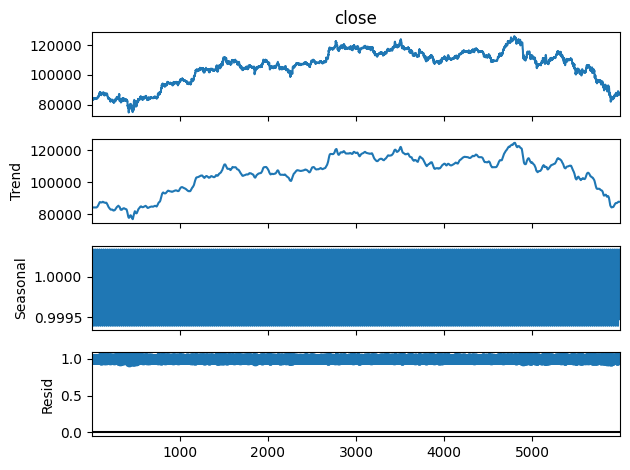

In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(btc_data['close'], model='mul', period=24)
decomposition.plot()
plt.show()

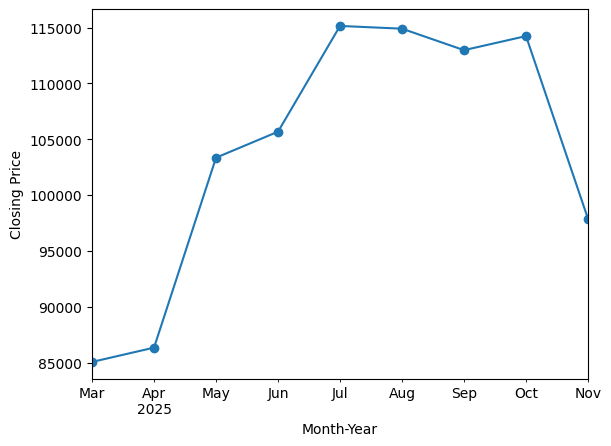

In [42]:
monthly = btc_data['close'].resample('M').mean()
monthly.plot(marker='o')
plt.ylabel('Closing Price')
plt.xlabel('Month-Year')
plt.show()

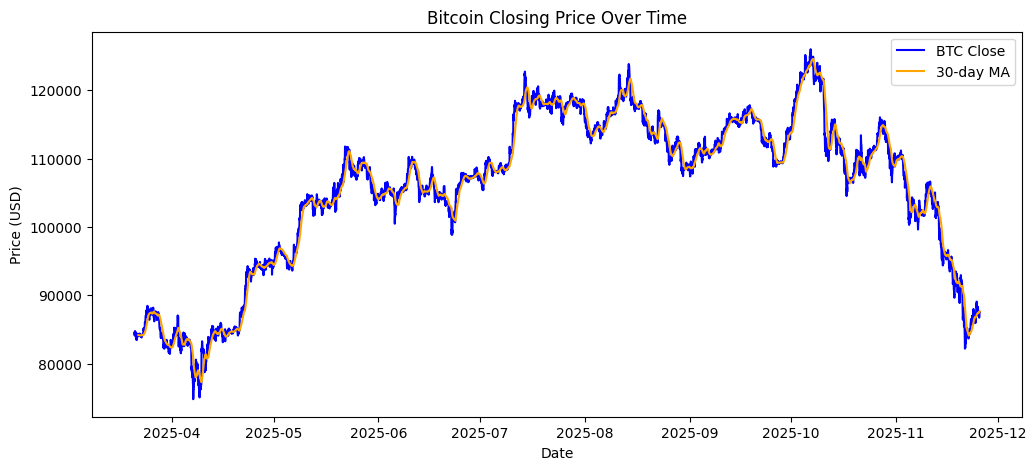

In [44]:
plt.figure(figsize=(12,5))
plt.plot(btc_data['close'], label='BTC Close', color='blue')
plt.plot(btc_data['close'].rolling(30).mean(), label='30-day MA', color='orange')
plt.title('Bitcoin Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()


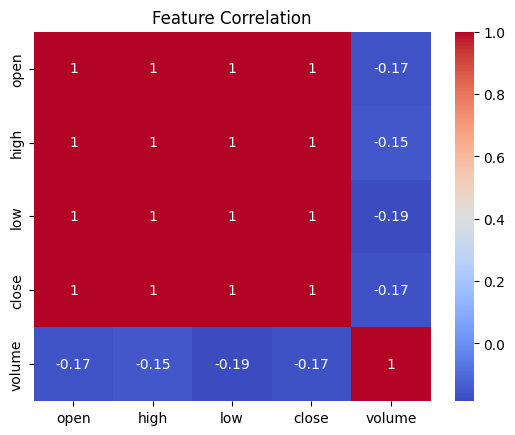

In [48]:
corr = btc_data[['open','high','low','close','volume']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()
